# Analysis of Task 4 

We will recreate the analysis we did in `analysis-t4.qmd`. 

Recall that Task 4 is the task where we ask the participant to find the highest sloped on the CDF (i.e., find mode on CDF). 

We ran the following models: 

- The Exponential model 
- The Lomax model  
- The Weibull model (this is also the best-performing model from LOO model comparison). 
- The Log-Normal model

Finally we compared all models in @sec-model-compare. 

In [1]:
import polars as pl
import pandas as pd
import pymc as pm
import arviz as az
import arviz_plots as azp

In [2]:
from utils import pp_check_dens_overlay, pp_check_pit_ecdf, pp_check_ecdf_overlay

In [4]:
# read in data 
task4_df = pl.read_csv("../../data/processed/task4.csv")
task4_df

participantId,task,id,rsp_time,status,data.select.x,data.select.y,pixel.select.x,pixel.select.y,param.mu,param.sigma,param.lambda,param.p,param.q,data.select.slope,data.ans.slope,pixelToMM,dist_to_screen,phy.select.x,phy.select.y,va.select.x,va.select.y,data.ans.x,data.ans.y,pixel.ans.x,pixel.ans.y,phy.ans.x,phy.ans.y,va.ans.x,va.ans.y
str,str,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""67f03733938aa3f0d17ce8a8""","""task4""",1,6.34,"""completed""",1.01,0.634547,371.535,159.353986,-0.05,0.94,0.5,3.79,3.59,0.343883,0.367885,4.6,668.258963,69.898913,54.488264,5.9876,4.669177,-0.05,0.25,314.825,311.25,57.570652,21.467391,4.932994,1.840432
"""67f03733938aa3f0d17ce8a8""","""task4""",2,5.652,"""completed""",-0.36,0.704049,298.24,131.900779,-1.23,1.12,0.11,3.23,19.54,0.283315,0.302315,4.6,668.258963,53.965217,60.456352,4.624406,5.179929,-1.23,0.445,251.695,234.225,43.846739,38.211957,3.758023,3.275358
"""67f03733938aa3f0d17ce8a8""","""task4""",3,4.847,"""completed""",1.72,0.516156,409.52,206.118235,1.38,0.76,0.31,2.3,21.45,0.490693,0.508989,4.6,668.258963,78.156522,44.322123,6.69343,3.798737,1.38,0.345,391.33,273.725,74.202174,29.625,6.355487,2.539599
"""67f03733938aa3f0d17ce8a8""","""task4""",4,5.566,"""completed""",-0.55,0.635886,288.075,158.825113,-0.61,0.62,-0.21,4.44,9.3,0.51476,0.514764,4.6,668.258963,51.755435,54.603236,4.435237,4.679019,-0.61,0.605,284.865,171.025,51.057609,51.951087,4.375495,4.451987
"""67f03733938aa3f0d17ce8a8""","""task4""",5,4.291,"""completed""",0.41,0.582029,339.435,180.09862,0.67,1.25,-0.33,2.12,43.26,0.317045,0.320102,4.6,668.258963,62.920652,49.978561,5.390766,4.28311,0.67,0.665,353.345,147.325,65.944565,57.103261,5.649432,4.892994
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""67ee2686d7cfcbbd9d87dd04""","""task4""",6,165.918,"""completed""",-0.74,0.137097,277.91,355.846488,-0.34,0.85,0.41,3.35,13.09,0.366305,0.403501,4.482353,587.915846,50.846063,12.081492,4.952156,1.177369,-0.34,0.295,299.31,293.475,55.620341,25.996391,5.416485,2.533085
"""67ee2686d7cfcbbd9d87dd04""","""task4""",7,166.334,"""completed""",-1.17,0.147631,254.905,351.685851,0.82,1.62,-0.06,3.59,30.61,0.155932,0.203024,4.482353,587.915846,45.713714,13.009718,4.452822,1.26782,0.82,0.53,361.37,200.65,69.465748,46.705381,6.761977,4.549316
"""67ee2686d7cfcbbd9d87dd04""","""task4""",8,53.856,"""completed""",0.97,0.80484,369.395,92.08802,1.06,0.55,-0.72,4.11,10.07,0.612879,0.612885,4.482353,587.915846,71.256102,70.925245,6.935835,6.903708,1.06,0.86,374.21,70.3,72.330315,75.786089,7.040134,7.375588


## Exponential Model 

The following is the math model: 

$$
\begin{align}
\text{error}_i &\sim \text{Exponential}(\lambda_{\text{PID}[i]}) \\ 
\log(\lambda_j) &\sim \mathcal{N}(\mu_\lambda, \sigma_\lambda) \\ 
\mu_\lambda &\sim \mathcal{N}(0, 1) \\ 
\sigma_\lambda &\sim \text{Half-Cauchy}(0, 1) 
\end{align}
$$

In [5]:
# prepare data 
def data_to_screen_slope(k):
    return k * 395 / 53.5

obv_error = abs((data_to_screen_slope(task4_df.select("data.select.slope")) - data_to_screen_slope(task4_df.select("data.ans.slope"))).to_numpy().flatten())

In [6]:
participant_ids = task4_df.select("participantId").to_numpy().flatten()
participant_idx, unq_pids = pd.factorize(participant_ids)

In [18]:
with pm.Model(coords = {
    "participant": unq_pids
}) as task4_exp:
    # hyperprior 
    sigma_lambda = pm.HalfCauchy("sigma_lambda", 1)
    mu_lambda = pm.Normal("mu_lambda", 0, 1)

    # non-centered parameterization
    log_lambda_offset = pm.Normal("log_lambda_offset", 0, 1, dims="participant")
    log_lambda = pm.Deterministic(
        "log_lambda", 
        mu_lambda + log_lambda_offset * sigma_lambda, 
        dims="participant"
    )
    
    p_lambda = pm.math.exp(log_lambda[participant_idx])

    # likelihood 
    error = pm.Exponential("error", p_lambda, observed=obv_error)

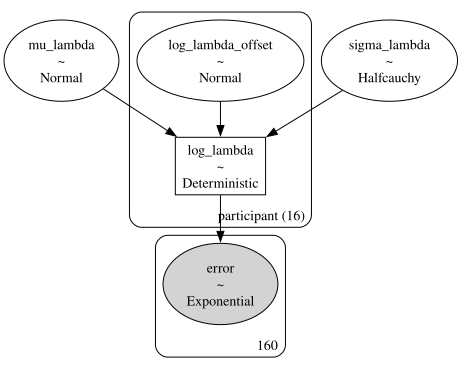

In [19]:
# check specification is correct 
pm.model_to_graphviz(task4_exp)

In [21]:
# fit 
with task4_exp:
    task4_exp_idata = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=4,
        target_accept=0.99,
        # random_seed = 42, 
        progressbar=False
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_lambda, mu_lambda, log_lambda_offset]
Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 8 seconds.


In [22]:
az.summary(task4_exp_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_lambda,1.865,0.394,1.107,2.603,0.011,0.007,1337.0,2085.0,1.0
log_lambda_offset[67f03733938aa3f0d17ce8a8],0.359,0.306,-0.221,0.936,0.007,0.004,2152.0,4104.0,1.0
log_lambda_offset[5c8f2ac8d7ecab0018d529aa],-1.445,0.429,-2.254,-0.650,0.011,0.005,1621.0,2820.0,1.0
log_lambda_offset[6740e1e09ca406ab781318cb],0.025,0.306,-0.557,0.601,0.007,0.004,2005.0,3652.0,1.0
log_lambda_offset[67e557aa25a43e8dde6c806c],-1.712,0.468,-2.571,-0.834,0.012,0.006,1575.0,2568.0,1.0
log_lambda_offset[67f441842da280dba751a76b],0.504,0.309,-0.091,1.067,0.007,0.004,2227.0,4339.0,1.0
log_lambda_offset[67f9736009c0ccdd5034f448],-0.026,0.309,-0.587,0.564,0.007,0.004,2036.0,4090.0,1.0
log_lambda_offset[67fbed03e8c70e38014c41b3],0.695,0.315,0.100,1.281,0.007,0.004,2162.0,4777.0,1.0
log_lambda_offset[558d8d71fdf99b534f79b352],0.944,0.330,0.291,1.547,0.007,0.004,2181.0,3880.0,1.0
log_lambda_offset[667433338e6cc9e53c828774],0.359,0.308,-0.241,0.918,0.006,0.004,2275.0,4721.0,1.0


array([[<Axes: title={'center': 'mu_lambda'}>, <Axes: title={'center': 'mu_lambda'}>],
       [<Axes: title={'center': 'log_lambda_offset'}>, <Axes: title={'center': 'log_lambda_offset'}>],
       [<Axes: title={'center': 'sigma_lambda'}>, <Axes: title={'center': 'sigma_lambda'}>],
       [<Axes: title={'center': 'log_lambda'}>, <Axes: title={'center': 'log_lambda'}>]], dtype=object)

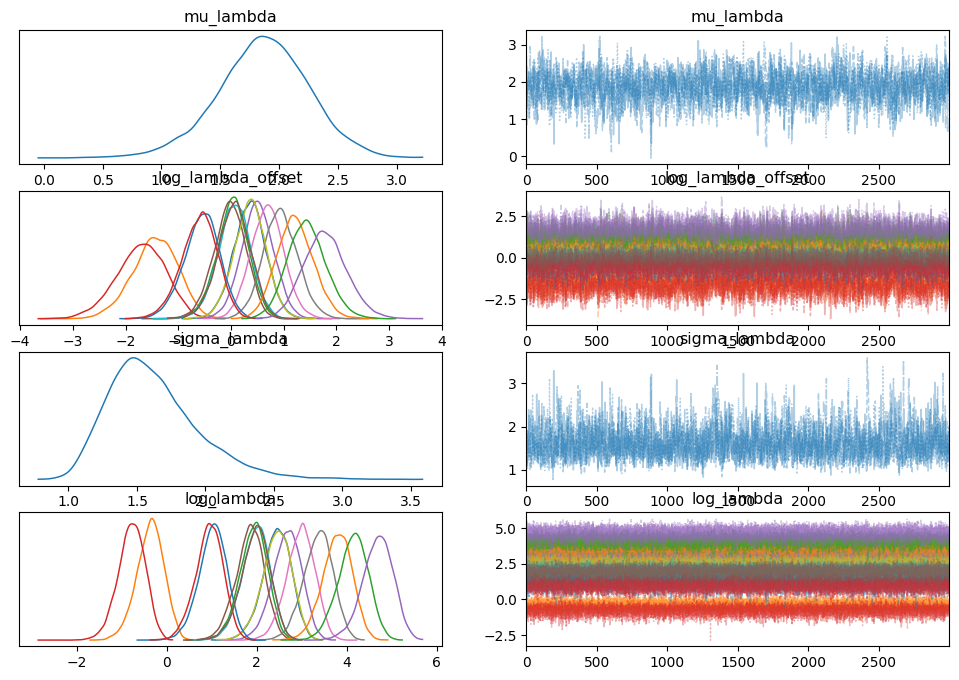

In [23]:
az.plot_trace(task4_exp_idata, combined=True)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

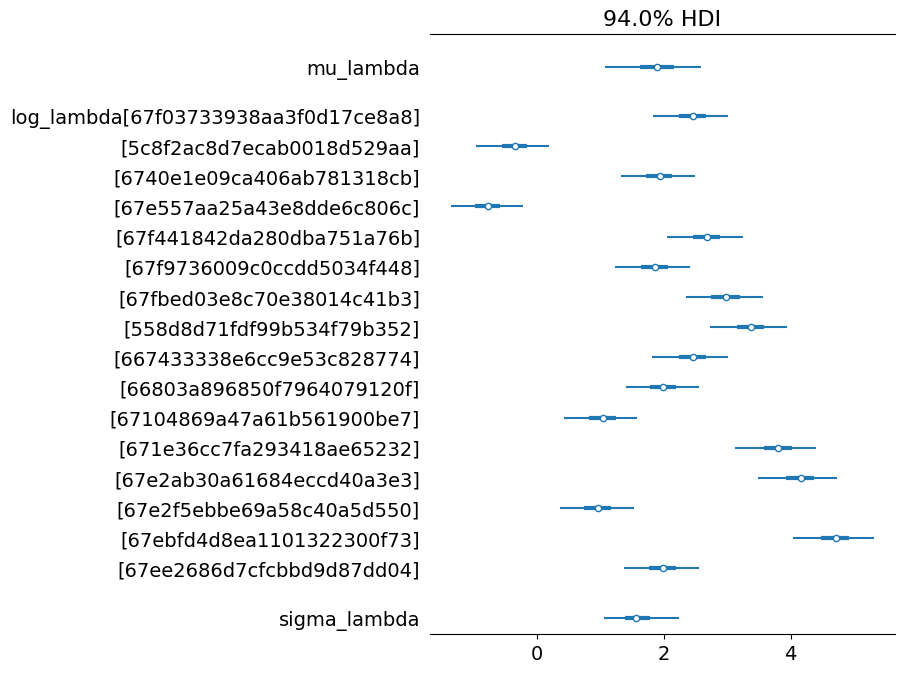

In [11]:
az.plot_forest(task4_exp_idata, combined=True)

In [24]:
# posterior predictive checks 
with task4_exp:
    pm.sample_posterior_predictive(task4_exp_idata, extend_inferencedata=True)
    pm.compute_log_likelihood(task4_exp_idata)

Sampling: [error]


Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00━━━━━━━  50% 0:00:01 / 0:00:00
Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:000;244m╸━━  95% 0:00:01


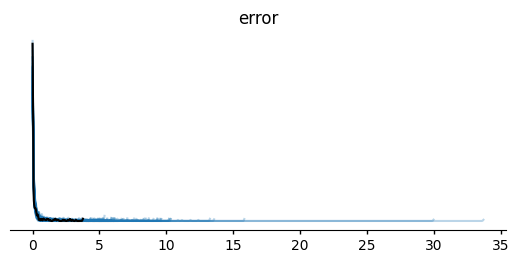

In [25]:
azp.plot_ppc_dist(task4_exp_idata)

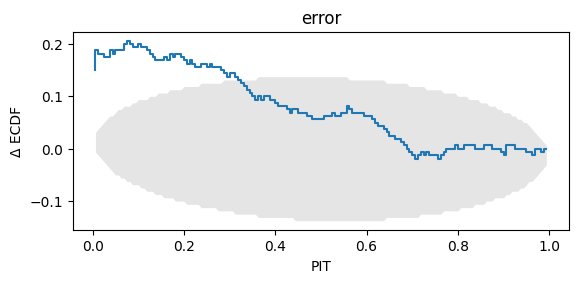

In [26]:
azp.plot_ppc_pit(task4_exp_idata)

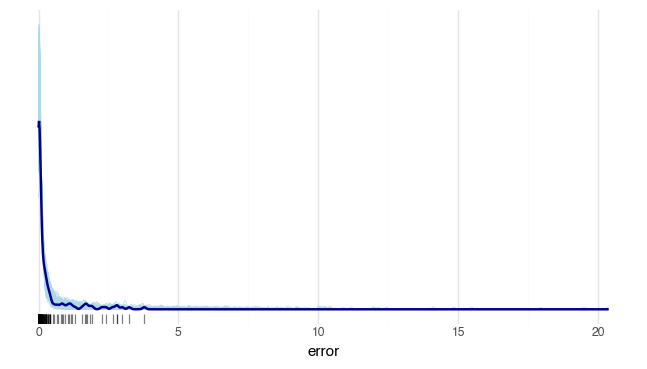

In [29]:
from plotnine import theme 
(
    pp_check_dens_overlay(task4_exp_idata, rug_on=True) + 
    theme(aspect_ratio = 0.5)
)

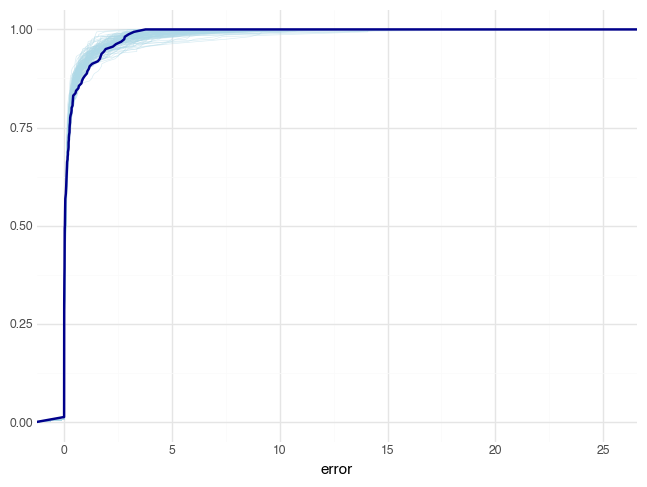

In [15]:
pp_check_ecdf_overlay(task4_exp_idata)

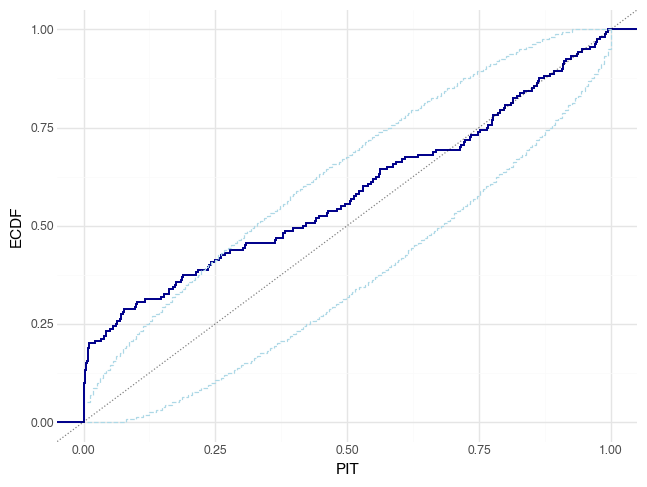

In [30]:
pp_check_pit_ecdf(task4_exp_idata)

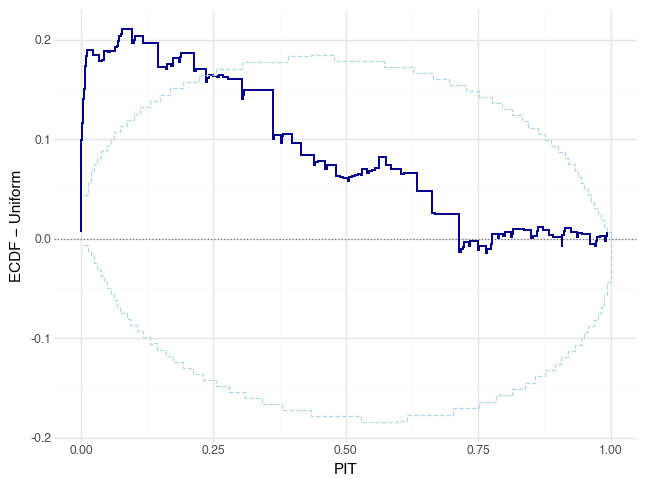

In [31]:
pp_check_pit_ecdf(task4_exp_idata, plot_diff=True)

The above tells us that the fit is not quite good ... 
We save the fitted model nonetheless ... 

In [32]:
# save fitted model 
task4_exp_idata.to_netcdf("../fitted_models/task4.exp.nc")

'../fitted_models/task4.exp.nc'

## Lomax model 

So the [Lomax distribution](https://en.wikipedia.org/wiki/Lomax_distribution) is just the Pareto distribution but with a small caveat --- i.e. it is shifted so that its support begins at zero. 

We will follow [this guide](https://www.pymc.io/projects/examples/en/stable/howto/custom_distribution.html) to create a custom distribution (the caveat is that this guide is kind of old now ...). It takes three steps: 

1. Define a log probability function 
2. Define the random generator function (which can be easily done if `scipy.stats` have it ...) 
    - Turns out that [`scipy.stats.lomax`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.lomax.html) is available 
3. Follow the `pymc` class definition 

In this [discussion](https://discourse.pymc.io/t/drawing-values-from-custom-distribution/10395/3) it appears that we don't necessarily have to define a custom class ...? So perhaps one should use this instead, the [`DensityDist`](https://www.pymc.io/projects/docs/en/v4.4.0/api/distributions/generated/pymc.DensityDist.html). 

Here's the math model: 

$$
\begin{align*}
\text{error}_i &\sim \text{Lomax}(\alpha_{\text{PID}[i]}, \lambda_{\text{PID}[i]}) \\ 
\log(\alpha_j) &\sim \mathcal{N}(\mu_\alpha, \sigma_\alpha) \\ 
\log(\lambda_j) &\sim \mathcal{N}(\mu_\lambda, \sigma_\lambda) \\ 
\mu_\alpha, \mu_\lambda &\sim \mathcal{N}(0, 1) \\ 
\sigma_\lambda, \sigma_\alpha &\sim \text{HalfCauchy}(0, 1)
\end{align*}
$$


In [33]:
# import pytensor.tensor as pt
# pm.math.log is pt.log returns True 
# so we don't need a new import 
def lomax_logp(x, alpha, scale):
    """
    alpha: shape parameter; alpha > 0 
    scale: scale parameter
    """
    return pm.math.log(alpha) + alpha * pm.math.log(scale) - (alpha + 1) * pm.math.log(x + scale)

In [34]:
# scipy.stats.lomax.rvs 
# can help us generated random samples ... 

from scipy.stats import lomax

def lomax_random(alpha, scale, rng, size):
    return lomax.rvs(c=alpha, loc=0, scale=scale, size=size)

In [35]:
with pm.Model(coords={
    "participant": unq_pids
}) as task4_lomax:
    # hyperpriors 
    sigma_lambda = pm.HalfCauchy("sigma_lambda", 1)
    sigma_alpha = pm.HalfCauchy("sigma_alpha", 1)
    mu_alpha = pm.Normal("mu_alpha", 0, 1)
    mu_lambda = pm.Normal("mu_lambda", 0, 1)

    # non-centered priors 
    z_alpha = pm.Normal("z_alpha", 0, 1, dims="participant")
    log_alpha = pm.Deterministic("log_alpha", mu_alpha + sigma_alpha * z_alpha, dims="participant")
    alpha = pm.math.exp(log_alpha[participant_idx])
    z_lambda = pm.Normal("z_lambda", 0, 1, dims="participant")
    log_lambda = pm.Deterministic("log_lambda", mu_lambda + sigma_lambda * z_lambda, dims="participant")
    lam = pm.math.exp(log_lambda[participant_idx])
    
    # define custom density distribution 
    pm.DensityDist('Lomax', alpha, lam, 
    logp=lomax_logp,
    observed=obv_error,
    random=lomax_random)

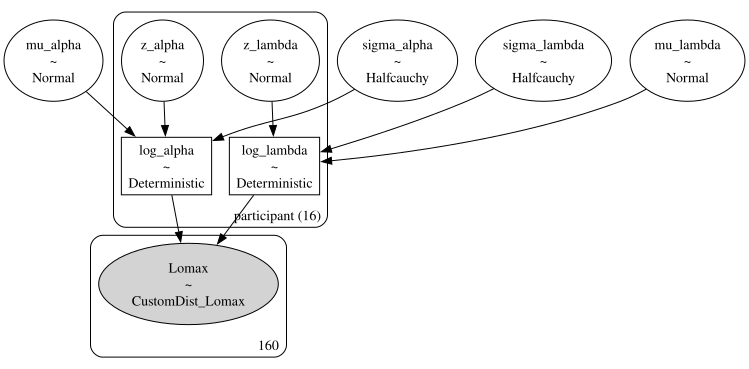

In [36]:
pm.model_to_graphviz(task4_lomax)

In [38]:
# fit the model 

with task4_lomax:
    task4_lomax_idata = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=4,
        target_accept=0.99,
        # max_treedepth=15, # takes too long to fit ... 
        # random_seed = 42, 
        progressbar=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_lambda, sigma_alpha, mu_alpha, mu_lambda, z_alpha, z_lambda]


                                                                                                         
  Progress          Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━   0       0             0.000       0            0.00 draws/s     0:00:00   -:--:--    
  ━━━━━━━━━━━━━━━   0       0             0.000       0            0.00 draws/s     0:00:00   -:--:--    
  ━━━━━━━━━━━━━━━   0       0             0.000       0            0.00 draws/s     0:00:00   -:--:--    
  ━━━━━━━━━━━━━━━   0       0             0.000       0            0.00 draws/s     0:00:00   -:--:--    
                                                                                                         
  Progress          Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ─────────────────────────────────────────────

KeyError: 0

In [61]:
az.summary(task4_lomax_idata)

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Program Files\Positron\resources\app\extensions\positron-python\python_files\lib\ipykernel\py3\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Positron\resources\app\extensions\positron-python\python_files\lib\ipykernel\py3\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
  File "C:\Users\slong\AppData\Roaming\uv\python\cpython-3.13.5-windows-x86_64-none\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.818,0.511,-1.340,0.121,0.248,0.128,5.0,12.0,3.06
mu_lambda,-1.395,1.087,-2.866,0.335,0.496,0.099,6.0,29.0,1.89
z_alpha[67f03733938aa3f0d17ce8a8],-0.145,0.578,-0.976,1.467,0.138,0.153,11.0,20.0,1.32
z_alpha[5c8f2ac8d7ecab0018d529aa],1.560,0.762,0.505,2.652,0.330,0.159,6.0,21.0,1.97
z_alpha[6740e1e09ca406ab781318cb],-0.242,0.508,-1.232,0.903,0.111,0.104,13.0,18.0,1.22
...,...,...,...,...,...,...,...,...,...
log_lambda[671e36cc7fa293418ae65232],-24.219,16.952,-63.994,-5.571,7.952,6.478,5.0,20.0,2.26
log_lambda[67e2ab30a61684eccd40a3e3],-189.239,320.077,-745.094,-2.377,159.823,92.269,6.0,18.0,1.69
log_lambda[67e2f5ebbe69a58c40a5d550],-0.691,1.028,-2.346,1.459,0.401,0.214,7.0,15.0,1.61
log_lambda[67ebfd4d8ea1101322300f73],-5.453,2.167,-8.521,-1.792,1.018,0.498,6.0,12.0,1.95


Yep the fit is quite bad ... won't be using this model at all ... 

TODO: double check whether it's a matter of fitting or something else ... e.g. is this the correct way to build up a custom distribution? 

In [ ]:
# class Lomax(pm.Continuous):
#     def __init__(self, alpha, lam, *args, **kwargs):
#         super().__init__(*args, **kwargs)
#         self.alpha = alpha
#         self.lam = lam # lambda 
#         self.mode = 0
#         self.median = self.lam * (2 ** (1/self.alpha) - 1)
    
#     def logp(self, value):
#         alpha = self.alpha
#         lam = self.lam
#         return lomax_logp(value, alpha, scale=lam)

#     def random(self, point=None, size=None):
#         alpha, lam = draw_values()

## Weibull distribution 

[PyMC Source](https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Weibull.html) --- alpha is the shape parameter and beta is the scale parameter ... 

[Wikipedia](https://en.wikipedia.org/wiki/Weibull_distribution) refers to shape as $k$ and scale as $\lambda$.

Math model: 

$$
\begin{align*}
\text{error}_i &\sim \text{Weibull}(\lambda_{\text{PID}[i]}, k_{\text{PID}[i]}) \\ 
\log(\lambda_j) &\sim \mathcal{N}(\mu_\lambda, \sigma_\lambda ) \\ 
\log(k_j) &\sim \mathcal{N}(\mu_k, \sigma_k) \\ 
\mu_\lambda, \mu_k &\sim \mathcal{N}(0, 1) \\ 
\sigma_\lambda, \sigma_k &\sim \text{HalfCauchy}(0, 1)
\end{align*}
$$

In [39]:
with pm.Model(coords = {
    "participant": unq_pids
}) as task4_weibull: 
    # hyperpriors 
    sigma_lambda = pm.HalfCauchy("sigma_lambda", 1)
    sigma_k = pm.HalfCauchy("sigma_k", 1)
    mu_lambda = pm.Normal("mu_lambda", 0, 1)
    mu_k = pm.Normal("mu_k", 0, 1)
    
    # priors 
    log_lambda = pm.Normal("log_lambda", mu_lambda, sigma_lambda, dims="participant")
    p_lambda = pm.math.exp(log_lambda[participant_idx])
    log_k = pm.Normal("log_k", mu_k, sigma_k, dims="participant")
    k = pm.math.exp(log_k[participant_idx])

    error = pm.Weibull("error", alpha=k, beta=p_lambda, observed=obv_error + 1e-6)

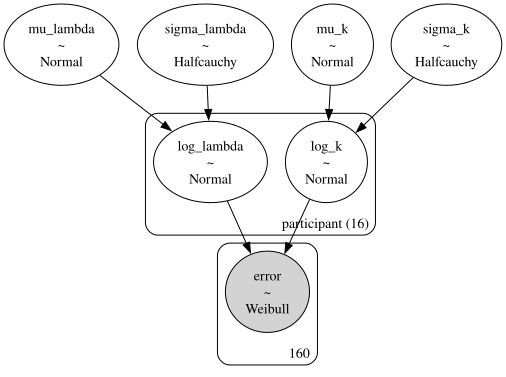

In [40]:
pm.model_to_graphviz(task4_weibull)

In [41]:
# fit the model 

with task4_weibull:
    task4_weibull_idata = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=4,
        target_accept=0.95,
        # random_seed = 42, 
        progressbar=False
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_lambda, sigma_k, mu_lambda, mu_k, log_lambda, log_k]
Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 4 seconds.


Note that we added `1e-6` to make the model fit (or else it won't fit because when error = 0 some of the log links goes into negative infinity ...)

In [42]:
az.summary(task4_weibull_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_lambda,-2.091,0.474,-2.981,-1.176,0.004,0.005,14213.0,8324.0,1.0
mu_k,-0.618,0.167,-0.929,-0.302,0.002,0.002,11222.0,8645.0,1.0
log_lambda[67f03733938aa3f0d17ce8a8],-2.802,0.763,-4.134,-1.235,0.006,0.009,15433.0,7995.0,1.0
log_lambda[5c8f2ac8d7ecab0018d529aa],0.468,0.233,0.021,0.886,0.003,0.004,9384.0,6328.0,1.0
log_lambda[6740e1e09ca406ab781318cb],-2.476,0.776,-3.890,-0.965,0.006,0.008,15959.0,8630.0,1.0
log_lambda[67e557aa25a43e8dde6c806c],0.897,0.206,0.489,1.264,0.003,0.004,8239.0,5151.0,1.0
log_lambda[67f441842da280dba751a76b],-3.129,0.796,-4.579,-1.590,0.006,0.009,15804.0,8097.0,1.0
log_lambda[67f9736009c0ccdd5034f448],-2.449,0.732,-3.834,-1.080,0.006,0.008,17581.0,9113.0,1.0
log_lambda[67fbed03e8c70e38014c41b3],-3.306,0.675,-4.576,-2.029,0.006,0.008,12628.0,7105.0,1.0
log_lambda[558d8d71fdf99b534f79b352],-3.591,0.625,-4.771,-2.424,0.005,0.008,15937.0,8239.0,1.0


array([[<Axes: title={'center': 'mu_lambda'}>, <Axes: title={'center': 'mu_lambda'}>],
       [<Axes: title={'center': 'mu_k'}>, <Axes: title={'center': 'mu_k'}>],
       [<Axes: title={'center': 'log_lambda'}>, <Axes: title={'center': 'log_lambda'}>],
       [<Axes: title={'center': 'log_k'}>, <Axes: title={'center': 'log_k'}>],
       [<Axes: title={'center': 'sigma_lambda'}>, <Axes: title={'center': 'sigma_lambda'}>],
       [<Axes: title={'center': 'sigma_k'}>, <Axes: title={'center': 'sigma_k'}>]], dtype=object)

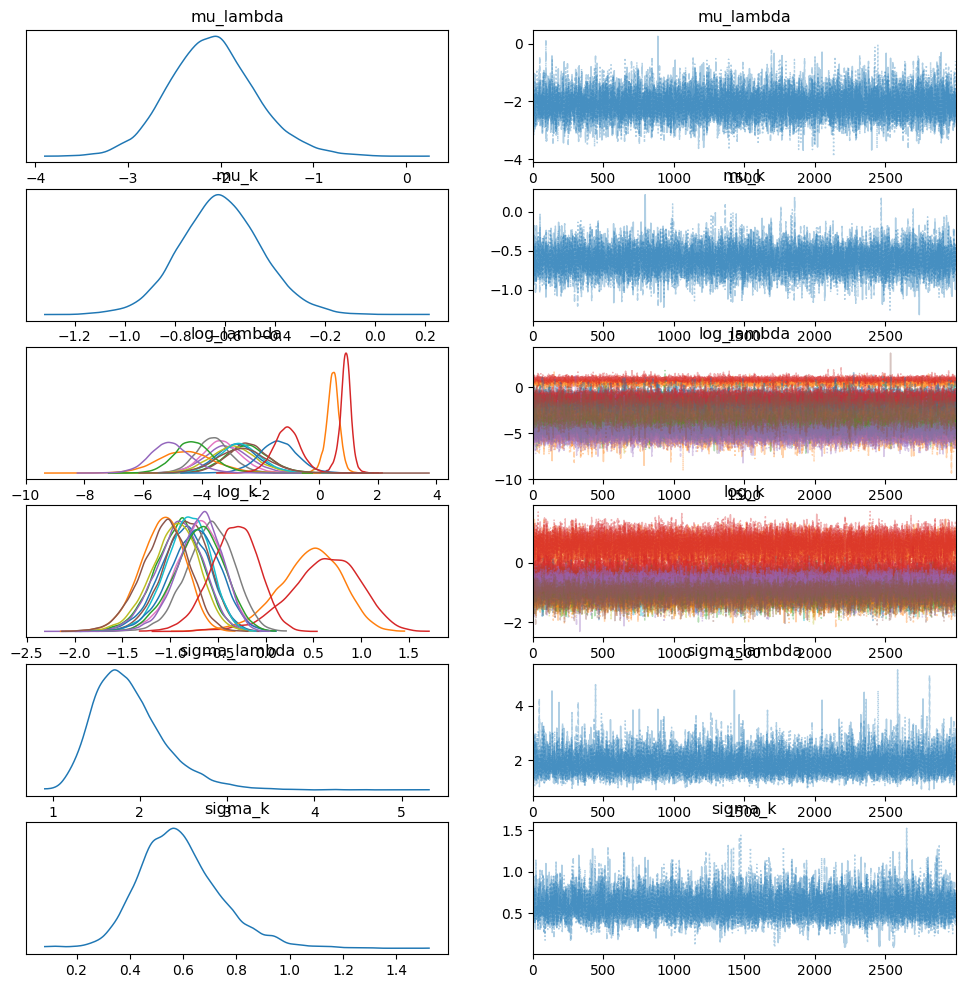

In [43]:
az.plot_trace(task4_weibull_idata, combined=True)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

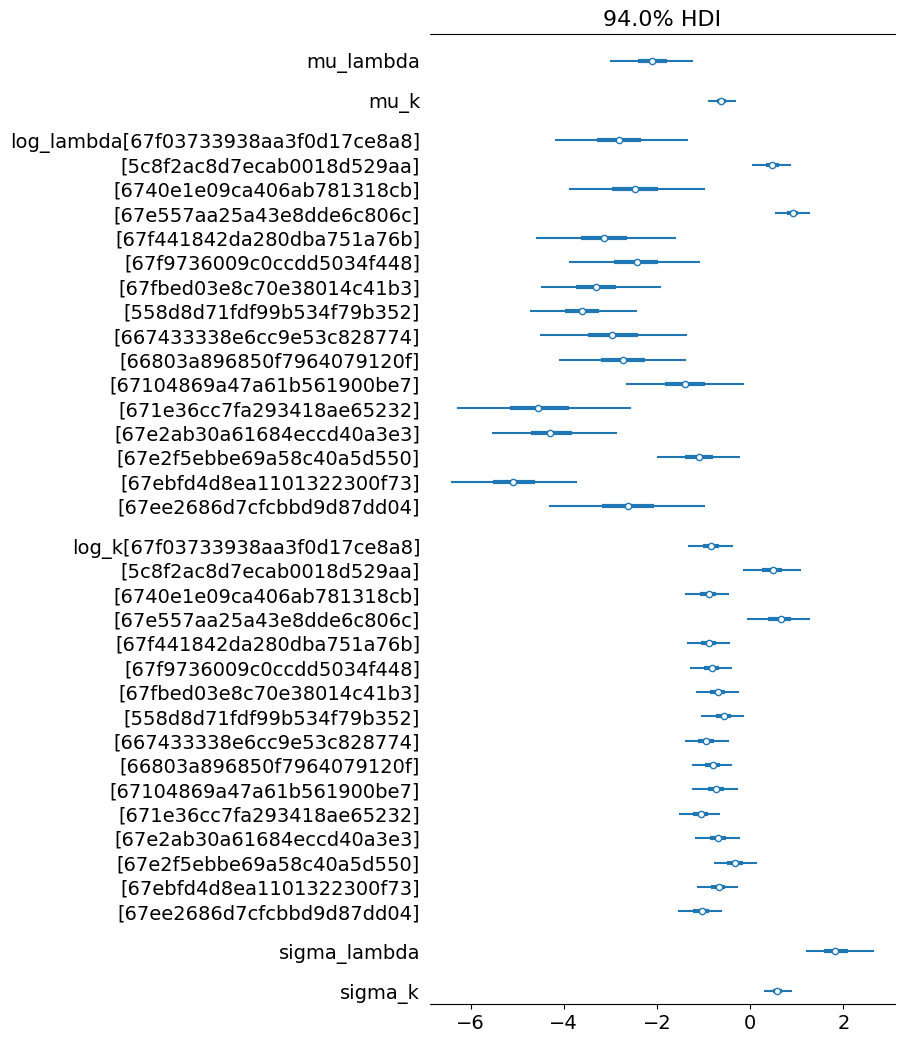

In [22]:
az.plot_forest(task4_weibull_idata, combined=True)

In [44]:
# posterior predictive check 
with task4_weibull:
    pm.sample_posterior_predictive(task4_weibull_idata, extend_inferencedata=True)
    pm.compute_log_likelihood(task4_weibull_idata)

Sampling: [error]


Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00m━━━━━━  83% 0:00:01 / 0:00:000:00:00
Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00237m━━━━━━━━━━━━━  65% 0:00:01


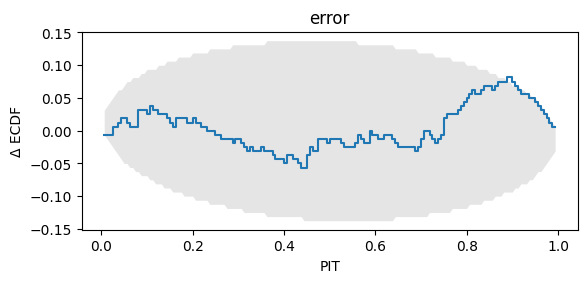

In [45]:
azp.plot_ppc_pit(task4_weibull_idata)

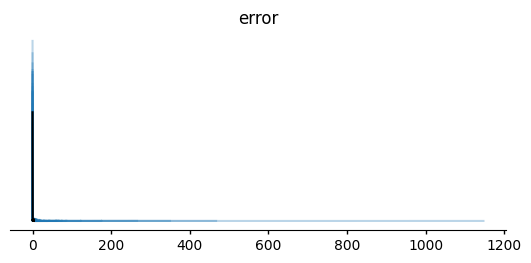

In [46]:
azp.plot_ppc_dist(task4_weibull_idata)

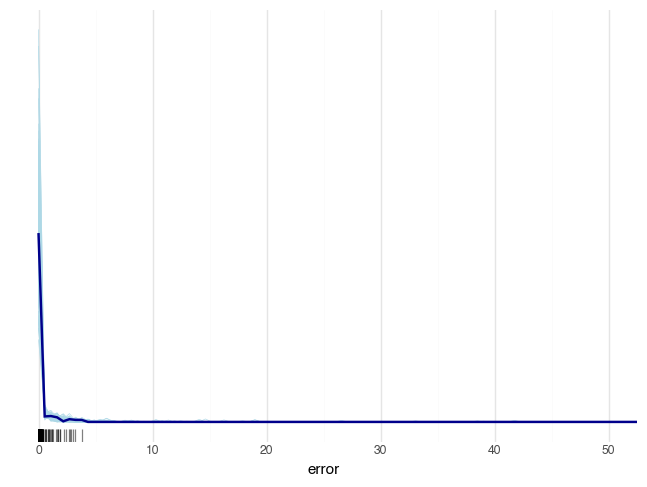

In [65]:
from plotnine import coord_cartesian
(
    pp_check_dens_overlay(task4_weibull_idata, rug_on=True) + 
    coord_cartesian(xlim = [0, 50])
)

hmm this plot is not very informative ... need to comapre to the other version to figure out what's wrong here ...

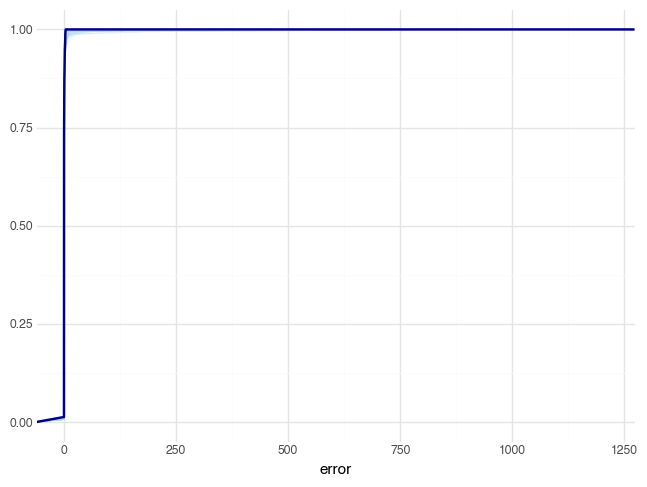

In [48]:
pp_check_ecdf_overlay(task4_weibull_idata)

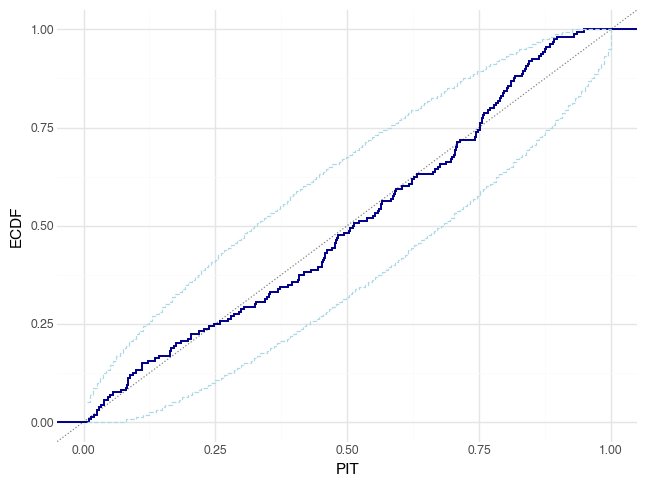

In [49]:
pp_check_pit_ecdf(task4_weibull_idata)

In [26]:
# save fitted data 
task4_weibull_idata.to_netcdf("../fitted_models/task4.weibull.nc")

'../fitted_models/task4.weibull.nc'

## Log-Normal distribution 

Math equation: 
$$
\begin{align*}
\text{error}_i &\sim \text{LogNormal}(\mu_{\text{PID}[i]}, \sigma_{\text{PID}[i]}) \\ 
\mu_j &\sim \mathcal{N}(\bar{\mu}, \tau_\mu) \\ 
\log(\sigma_j) &\sim \mathcal{N}(\bar{\sigma}, \tau_\sigma) \\ 
\bar{\mu}, \bar{\sigma} &\sim \mathcal{N}(0, 1) \\ 
\tau_\mu, \tau_\sigma &\sim \text{HalfCauchy}(0, 1)
\end{align*}
$$

In [50]:
with pm.Model(coords={
    "participant": unq_pids
}) as task4_logNorm:
    # hyperpriors 
    tau_mu = pm.HalfCauchy("tau_mu", 1)
    tau_sigma = pm.HalfCauchy("tau_sigma", 1)
    mu_bar = pm.Normal("mu_bar", 0, 1)
    sigma_bar = pm.Normal("sigma_bar", 0, 1)
    # priors 
    mu = pm.Normal("mu", mu_bar, tau_mu, dims="participant")
    log_sigma = pm.Normal("log_sigma", sigma_bar, tau_sigma, dims="participant")
    sigma = pm.math.exp(log_sigma[participant_idx])

    error = pm.LogNormal("error", mu[participant_idx], sigma, observed=obv_error + 1e-6)

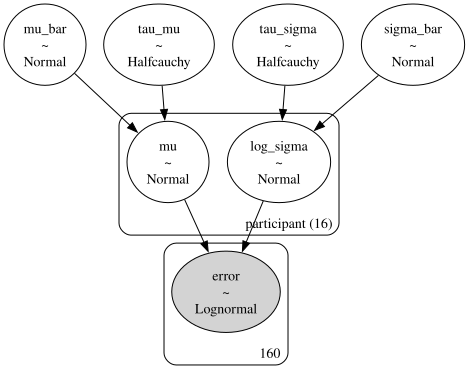

In [51]:
pm.model_to_graphviz(task4_logNorm)

In [52]:
# fit the model 
with task4_logNorm:
    task4_logNorm_idata = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed = 42, 
        progressbar=False
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau_mu, tau_sigma, mu_bar, sigma_bar, mu, log_sigma]
Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 4 seconds.


In [53]:
az.summary(task4_logNorm_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_bar,-2.689,0.626,-3.856,-1.520,0.006,0.006,12878.0,7974.0,1.0
sigma_bar,0.909,0.190,0.549,1.271,0.002,0.002,15807.0,9373.0,1.0
mu[67f03733938aa3f0d17ce8a8],-4.199,1.084,-6.226,-2.132,0.008,0.012,17633.0,7542.0,1.0
mu[5c8f2ac8d7ecab0018d529aa],0.291,0.224,-0.121,0.696,0.002,0.004,11777.0,6841.0,1.0
mu[6740e1e09ca406ab781318cb],-3.931,1.109,-5.980,-1.806,0.008,0.013,18272.0,7562.0,1.0
mu[67e557aa25a43e8dde6c806c],0.759,0.193,0.381,1.115,0.002,0.003,13215.0,6870.0,1.0
mu[67f441842da280dba751a76b],-4.554,1.123,-6.642,-2.419,0.008,0.012,19199.0,9076.0,1.0
mu[67f9736009c0ccdd5034f448],-3.752,0.969,-5.488,-1.854,0.007,0.010,18636.0,7215.0,1.0
mu[67fbed03e8c70e38014c41b3],-4.427,0.881,-6.075,-2.716,0.007,0.010,16738.0,7940.0,1.0
mu[558d8d71fdf99b534f79b352],-4.583,0.744,-5.962,-3.182,0.006,0.009,16183.0,7498.0,1.0


In [54]:
# posterior predictive check 
with task4_logNorm:
    pm.sample_posterior_predictive(task4_logNorm_idata, extend_inferencedata=True)
    pm.compute_log_likelihood(task4_logNorm_idata)

Sampling: [error]


Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00;237m━━━━━━━━━  77% 0:00:01 / 0:00:00
Computing ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:005;237m━━━━━━━━━━━  71% 0:00:01


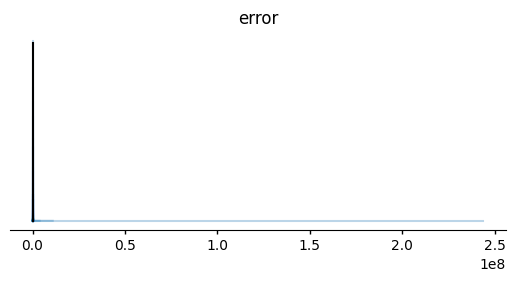

In [55]:
azp.plot_ppc_dist(task4_logNorm_idata)

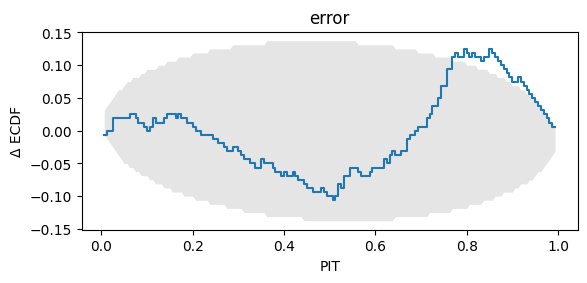

In [56]:
azp.plot_ppc_pit(task4_logNorm_idata)

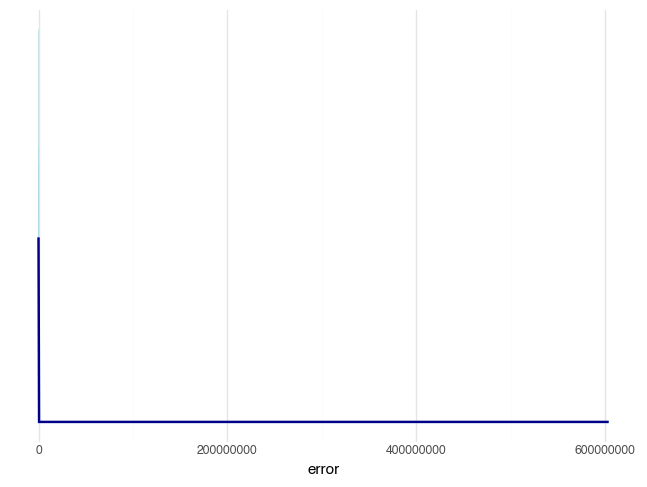

In [57]:
pp_check_dens_overlay(task4_logNorm_idata)

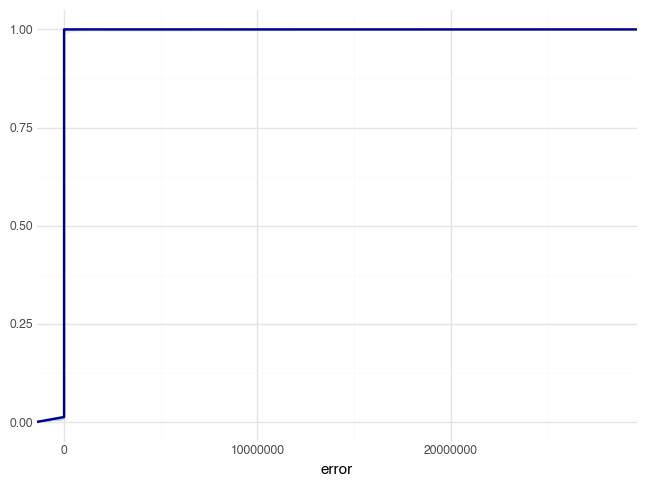

In [58]:
pp_check_ecdf_overlay(task4_logNorm_idata)

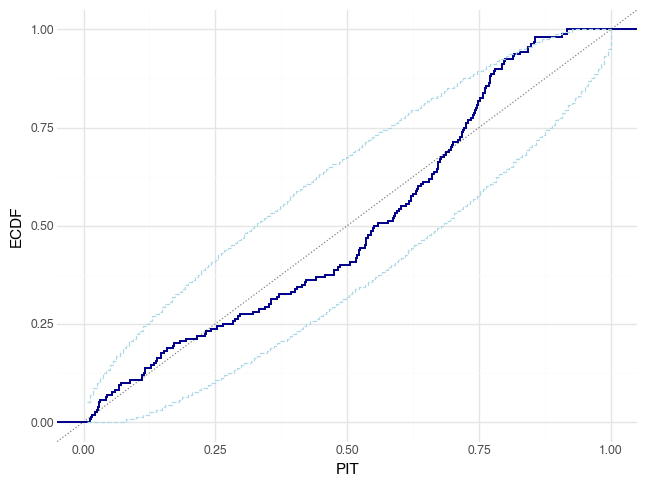

In [59]:
pp_check_pit_ecdf(task4_logNorm_idata)

In [35]:
# save fitted data 
task4_logNorm_idata.to_netcdf("../fitted_models/task4.lognorm.nc")

'../fitted_models/task4.lognorm.nc'

## LOO Comparison 

In [36]:
df_comp_loo = az.compare({
    "exp": task4_exp_idata, 
    "weibull": task4_weibull_idata, 
    "lognorm": task4_logNorm_idata
})
df_comp_loo

C:\Users\slong\Downloads\vis-decode-analysis\.venv\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
C:\Users\slong\Downloads\vis-decode-analysis\.venv\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
C:\Users\slong\Downloads\vis

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
weibull,0,265.824120,26.304724,0.000000,0.868989,35.367052,0.000000,True,log
lognorm,1,247.140714,29.483847,18.683406,0.000000,36.715314,4.229254,True,log
exp,2,173.875738,28.538285,91.948382,0.131011,26.748950,20.215680,True,log


By looking at the detailed results, I think we're getting this because of the `obv_error == 0` cases (which is 2). 

In [37]:
az.loo(task4_weibull_idata, pointwise=True)

C:\Users\slong\Downloads\vis-decode-analysis\.venv\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 12000 posterior samples and 160 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   265.82    35.37
p_loo       26.30        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      157   98.1%
   (0.70, 1]   (bad)         3    1.9%
   (1, Inf)   (very bad)    0    0.0%